In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = pd.read_csv("/kaggle/input/project-3-ai-ml-core/train.csv")
test_df = pd.read_csv("/kaggle/input/project-3-ai-ml-core/test.csv")
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
test_df.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
y_train = train_df['label'].values
X_train = train_df.drop(columns = 'label').values
X_test = test_df.values

split = int(0.8 * len(X_train))

X_train_split = X_train[:split]
X_val = X_train[split:]
y_train_split = y_train[:split]
y_val = y_train[split:]

print(len(X_train_split))
print(len(X_val))
print(len(y_train_split))
print(len(y_val))

X_train_normalized = X_train_split.reshape(-1, 28, 28) / 255.0
X_val_normalized = X_val.reshape(-1, 28, 28) / 255.0
test_normalized = X_test.reshape(-1, 28, 28) / 255.0

33600
8400
33600
8400


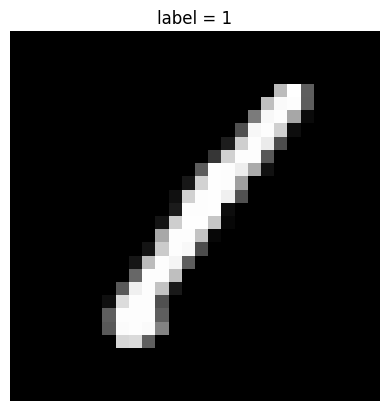

In [4]:
def view_digits(image_array, label=None):
    plt.imshow(image_array, cmap='gray')
    if label is not None:
        plt.title(f"label = {label}")
    plt.axis('off');
    plt.show()

view_digits(X_train_normalized[0], y_train[0])

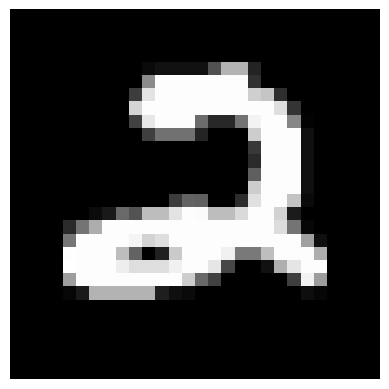

In [5]:
view_digits(test_normalized[0])

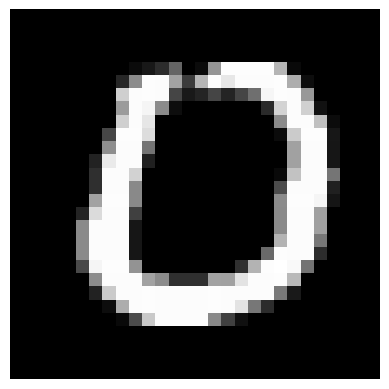

In [6]:
view_digits(X_val_normalized[0])

In [7]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - (np.tanh(x))**2

In [8]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mse_loss_derivative(y_true, y_pred):
    N = y_true.shape[0]
    return 2 * (y_pred - y_true) / N

def crossentropy_loss(y_true, y_pred):
    epsilon = 1e-12
    N = y_true.shape[0]
    y_pred = np.clip(y_pred, epsilon, 1-epsilon)
    loss = -np.sum(y_true * np.log(y_pred)) / N
    return loss

def crossentropy_loss_derivative(y_true, y_pred):
    return y_pred - y_true

In [9]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# def softmax_jacobian_per_batch(a):
#     N, C = a.shape
#     jacobian = np.zeros((N, C, C))
#     for i in range(N):
#         ai = a[i].reshape(-1, 1)
#         jacobian[i] = np.diagflat(ai) - np.dot(ai, ai.T)
#     return jacobian

# def computingof_dz2(d_a2, a):
#     jacobian = softmax_jacobian_per_batch(a)
#     d_z2 = np.einsum('nij,nj->ni', jacobian, d_a2)
#     return d_z2

In [10]:
class NN:
    def __init__(self, input_size, hidden_size, output_size,
                 activation, activation_deri,
                 loss, loss_deri,
                 learning_rate=0.01):

        self.w1 = np.random.randn(input_size, hidden_size)*0.01
        self.b1 = np.zeros((1, hidden_size))
        self.w2 = np.random.randn(hidden_size, output_size)*0.01
        self.b2 = np.zeros((1, output_size))

        self.activation = activation
        self.activation_deri = activation_deri
        self.loss = loss
        self.loss_deri = loss_deri
        self.learning_rate = learning_rate

    def forward(self, X):
        self.z1 = np.dot(X, self.w1) + self.b1
        self.a1 = self.activation(self.z1)
        self.z2 = np.dot(self.a1, self.w2) + self.b2
        
        if self.loss == crossentropy_loss:
            self.a2 = softmax(self.z2)
        elif self.loss == mse_loss:
            self.a2 = self.z2
        
        return self.a2

    def backward(self, X, y):
        N = X.shape[0]

        d_a2 = self.loss_deri(y, self.a2)
        d_z2 = d_a2
        
        d_w2 = np.dot(self.a1.T, d_z2) / N
        d_b2 = np.sum(d_z2, axis=0, keepdims=True) / N
        
        d_a1 = np.dot(d_z2, self.w2.T)
        d_z1 = d_a1 * self.activation_deri(self.z1)
        d_w1 = np.dot(X.T, d_z1) / N
        d_b1 = np.sum(d_z1, axis=0, keepdims=True) / N
        
        self.w1 -= self.learning_rate * d_w1
        self.b1 -= self.learning_rate * d_b1
        self.w2 -= self.learning_rate * d_w2
        self.b2 -= self.learning_rate * d_b2

In [11]:
X_train_flat = X_train_normalized.reshape(-1, 784)
X_val_flat = X_val_normalized.reshape(-1, 784)

In [12]:
def train(nn, X_train, y_train, X_val, y_val, epochs=20, batch_size=100):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        indices = np.arange(X_train.shape[0])
        np.random.shuffle(indices)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        for start in range(0, X_train.shape[0], batch_size):
            end = start + batch_size
            X_batch = X_train_shuffled[start:end]
            y_batch = y_train_shuffled[start:end]
            nn.forward(X_batch)
            nn.backward(X_batch, y_batch)

        y_train_pred = nn.forward(X_train)
        train_loss = nn.loss(y_train, y_train_pred)
        train_acc = np.mean(np.argmax(y_train, axis=1) == np.argmax(y_train_pred, axis=1))

        y_val_pred = nn.forward(X_val)
        val_loss = nn.loss(y_val, y_val_pred)
        val_acc = np.mean(np.argmax(y_val, axis=1) == np.argmax(y_val_pred, axis=1))

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'''Epoch {epoch+1}/{epochs} 
        - Train Loss: {train_loss:.4f} 
        - Val Loss: {val_loss:.4f} 
        - Train Acc: {train_acc:.4f} 
        - Val Acc: {val_acc:.4f}''')

    return history

In [13]:
def one_hot_encode(labels, num_classes=10):
    return np.eye(num_classes)[labels]

y_train_oh = one_hot_encode(y_train_split, 10)
y_val_oh = one_hot_encode(y_val, 10)

In [14]:
input_size = 784
hidden_size = 128
output_size = 10
all_histories = {}
all_models = {}

permutations = [
    ('relu_mse', relu, relu_derivative, mse_loss, mse_loss_derivative),
    ('relu_ce', relu, relu_derivative, crossentropy_loss, crossentropy_loss_derivative),
    ('sigmoid_mse', sigmoid, sigmoid_derivative, mse_loss, mse_loss_derivative),
    ('sigmoid_ce', sigmoid, sigmoid_derivative, crossentropy_loss, crossentropy_loss_derivative),
    ('tanh_mse', tanh, tanh_derivative, mse_loss, mse_loss_derivative),
    ('tanh_ce', tanh, tanh_derivative, crossentropy_loss, crossentropy_loss_derivative),
]

results = []

for name, act, act_deriv, loss, loss_deriv in permutations:
    print(f"\nTraining: {name}")
    
    nn = NN(
        input_size=input_size,
        hidden_size=hidden_size,
        output_size=output_size,
        activation=act,
        activation_deri=act_deriv,
        loss=loss,
        loss_deri=loss_deriv,
        learning_rate=0.01
    )
    
    history = train(nn, X_train_flat, y_train_oh, X_val_flat, y_val_oh)
    all_histories[name] = history
    all_models[name] = nn
    
    results.append({
        'activation': name,
        'loss': loss.__name__,
        'final_train_acc': history['train_acc'][-1],
        'final_train_loss': history['train_loss'][-1],
        'val_acc': history['val_acc'][-1],
        'val_loss': history['val_loss'][-1]
    })


Training: relu_mse
Epoch 1/20 
        - Train Loss: 0.0983 
        - Val Loss: 0.0983 
        - Train Acc: 0.1669 
        - Val Acc: 0.1655
Epoch 2/20 
        - Train Loss: 0.0967 
        - Val Loss: 0.0967 
        - Train Acc: 0.1835 
        - Val Acc: 0.1814
Epoch 3/20 
        - Train Loss: 0.0953 
        - Val Loss: 0.0953 
        - Train Acc: 0.1980 
        - Val Acc: 0.1989
Epoch 4/20 
        - Train Loss: 0.0941 
        - Val Loss: 0.0941 
        - Train Acc: 0.2174 
        - Val Acc: 0.2165
Epoch 5/20 
        - Train Loss: 0.0930 
        - Val Loss: 0.0930 
        - Train Acc: 0.2416 
        - Val Acc: 0.2420
Epoch 6/20 
        - Train Loss: 0.0921 
        - Val Loss: 0.0921 
        - Train Acc: 0.2747 
        - Val Acc: 0.2751
Epoch 7/20 
        - Train Loss: 0.0914 
        - Val Loss: 0.0914 
        - Train Acc: 0.3160 
        - Val Acc: 0.3150
Epoch 8/20 
        - Train Loss: 0.0907 
        - Val Loss: 0.0907 
        - Train Acc: 0.3583 
      

In [15]:
df = pd.DataFrame(results)
df = df.sort_values('val_acc', ascending=False).reset_index(drop=True)
df['rank'] = df['val_acc'].rank(ascending=False, method='min').astype(int)
df = df[['rank', 'activation', 'loss', 'final_train_acc', 'final_train_loss', 'val_acc', 'val_loss']]
df

,rank,activation,loss,final_train_acc,final_train_loss,val_acc,val_loss
0,1,relu_ce,crossentropy_loss,0.914256,0.300111,0.913810,0.301609
1,2,tanh_ce,crossentropy_loss,0.912560,0.305805,0.910595,0.307895
2,3,sigmoid_ce,crossentropy_loss,0.838542,0.629240,0.840833,0.624155
3,4,tanh_mse,mse_loss,0.646488,0.082764,0.650714,0.082658
4,5,relu_mse,mse_loss,0.621280,0.086410,0.630238,0.086389
5,6,sigmoid_mse,mse_loss,0.141339,0.089408,0.148690,0.089399


In [16]:
def plot_train_metrics(history, name):
    epochs = range(1, len(history['train_acc']) + 1)
    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Train Accuracy', color='tab:blue')
    ax1.plot(epochs, history['train_acc'], color='tab:blue', label='Train Accuracy')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Train Loss', color='tab:red')
    ax2.plot(epochs, history['train_loss'], color='tab:red', label='Train Loss')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title(f'Training Accuracy and Loss for {name}')
    fig.tight_layout()
    plt.show()

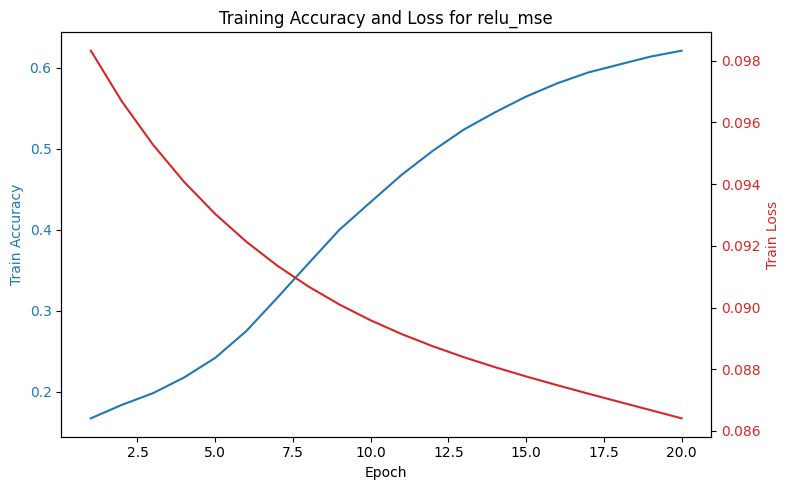

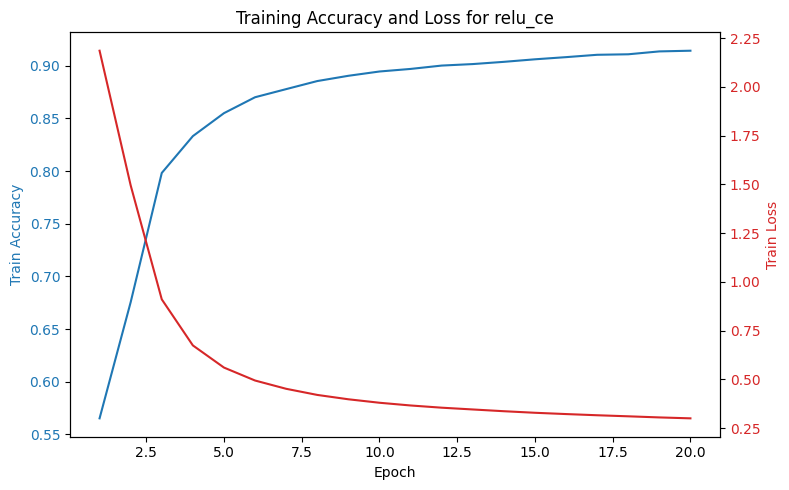

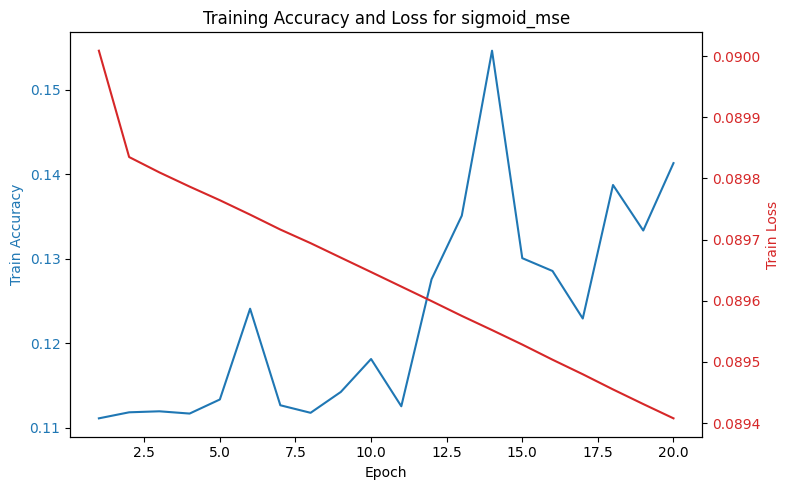

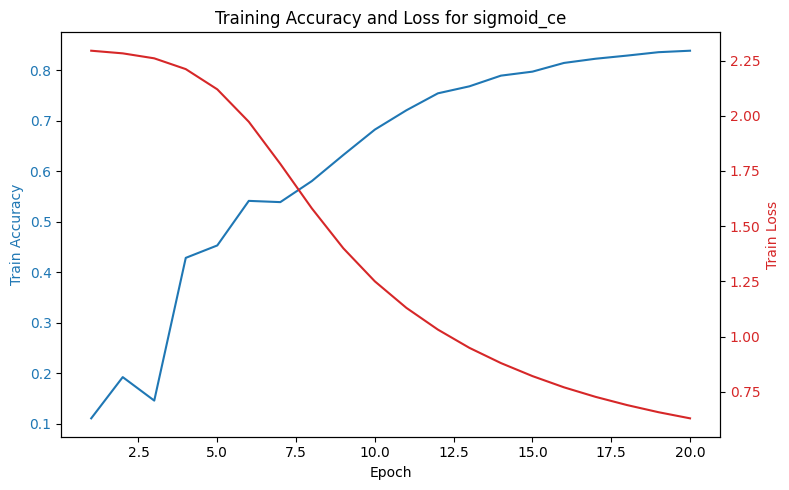

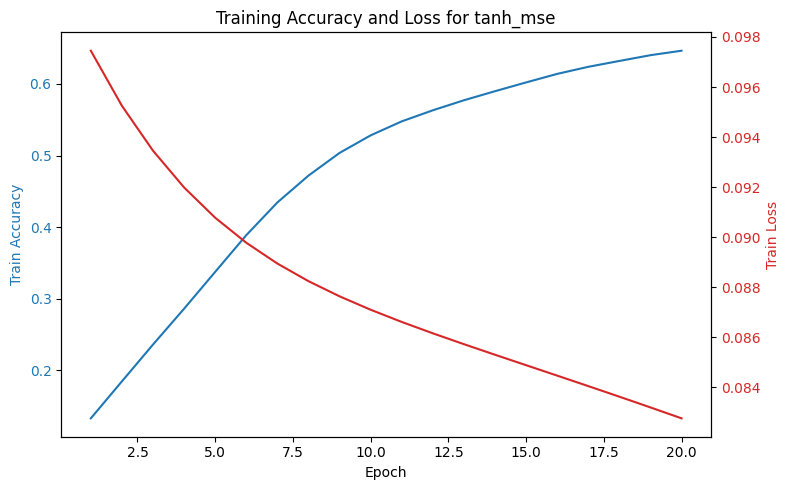

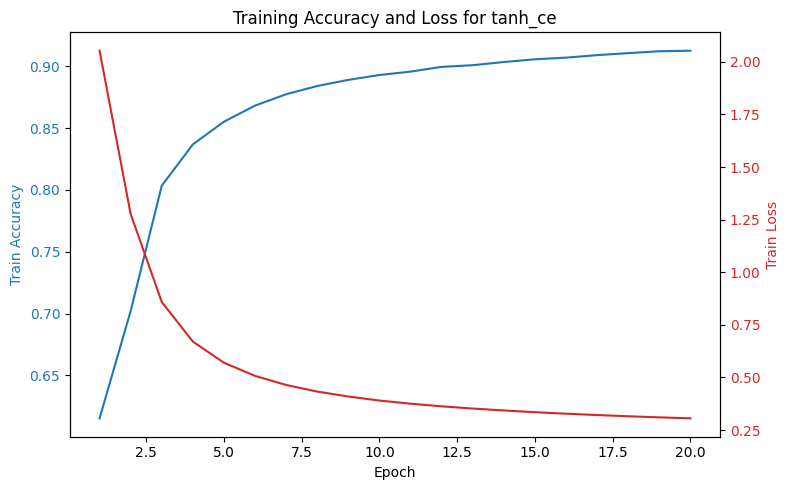

In [17]:
for name in all_histories:
    plot_train_metrics(all_histories[name], name)

In [18]:
nn_relu_ce = all_models['relu_ce']

X_test_flat = test_normalized.reshape(test_normalized.shape[0], -1)

def predict(nn, X):
    y_pred = nn.forward(X)
    return np.argmax(y_pred, axis=1)

test_preds = predict(nn_relu_ce, X_test_flat)

In [19]:
submission = pd.DataFrame({
    'ImageId': np.arange(1, len(test_preds) + 1),
    'Label': test_preds
})

submission.to_csv('my_submission_final.csv', index=False)